# EDA quickstart — `papers_benchset_v1.parquet`

**Start here if this is your first time in the benchmark corpus.**
`data/processed/papers_benchset_v1.parquet` is 28 published systematic-review screening
collections — 181,199 papers, each read by the researchers who ran that review and marked
relevant or not. It's built by `notebooks/main/01_data_compile_benchset_v1.ipynb`, which
verifies every file against the corpus's own `manifest.json` before writing it.

This is the benchmark-corpus twin of `02_eda_quickstart.ipynb`. Same five slides, same
palette, same export convention — but read the two differences below before reading any
chart, because they change what the numbers *mean*, not just what they are.

### 1. The pooled number is the misleading one

`papers_combined.parquet` is 37% positive and pooling its six use cases is mostly
harmless. This corpus is **1.86% positive**, and per collection it runs anywhere from
**0.16% to 78%**. A model answering "not relevant" every time scores 98% accuracy here
and is worthless. So: **accuracy is never quoted in this notebook**, and every slide that
could be read as a corpus-wide claim is shown per collection beside it.

Related, and stricter: the corpus README's second rule is **never mix the collections
into one training pool**. Each question is its own world. This file pools them for
storage only — every row carries `use_case_key`.

### 2. A missing abstract is a genuine NULL here

The exact reverse of the TIRI corpus, where it is an empty string and
`02_eda_quickstart.ipynb` §4 warns you that `abstract.isna()` reports zero. Here
`.isna()` is right and an `== ""` test finds nothing. `has_abstract` (added by 01) is
still the flag to use either way.

### Columns worth knowing

- **`row_key`** — the unique key: `use_case_key + "__" + paper_id`. Use this, not
  `paper_id`, which is a content fingerprint and repeats across collections *on purpose*
  (3,137 papers were screened for more than one question).
- **`use_case_key`** / **`use_case_name`** — which of the 28 questions a row belongs to.
- **`triage_label`** — `positive` or `negative`. No third class, no nulls: every row in
  this corpus was screened.
- **`objective`** / **`problem_statement`** / **`terms_*`** — that question's brief,
  broadcast onto every row. LLM-drafted from the review's own title and abstract and
  never from the labels, but still synthetic — see `01`'s header.

In [1]:
import sys
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "../../scripts")

DATA_PATH = Path("../../data/processed/papers_benchset_v1.parquet")
CACHE_DIR = Path("../../data/processed/embeddings_cache")
REPORTS_DIR = Path("../../reports")

# Same label/use-case colour language as 02_eda_quickstart.ipynb and
# scripts/latent_space_utils.py. 'pass' has no analogue here — this corpus is binary.
LABEL_COLORS = {"positive": "#2ca02c", "negative": "#d62728"}
LABEL_DISPLAY = {"positive": "Relevant", "negative": "Not relevant"}
LABEL_ORDER = ["positive", "negative"]

# 28 collections is too many for the 6-entry USE_CASE_COLORS list the TIRI notebook uses,
# and a 28-colour categorical scale is unreadable anyway. Colour by SOURCE FAMILY instead
# — the distinction that actually matters when reading these charts — reusing three
# values from that same palette.
FAMILY_COLORS = {
    "SYNERGY": "#2a78d6",
    "EV charging (Nykvist)": "#1baf7a",
    "Road freight (review-of-reviews)": "#eb6834",
}
EXCLUDE_FROM_HEADLINE = "roadfreight_metareview"
MIN_POSITIVES_TO_SPLIT = 40

FEATURE_DISPLAY = {
    "title": "Title", "abstract_present": "Abstract", "authors": "Authors",
    "year": "Year", "doi": "DOI", "citation_count": "Citations",
    "citation_count_log1p": "Citations", "paper_age": "Paper Age",
    "n_authors": "Number of Authors", "n_papers": "Papers",
}


def family_of(key):
    if key.startswith("synergy_"):
        return "SYNERGY"
    if key == EXCLUDE_FROM_HEADLINE:
        return "Road freight (review-of-reviews)"
    return "EV charging (Nykvist)"


def display_name(key):
    # Derived, not hand-curated: 02_eda_quickstart.ipynb hand-writes 6 display names, but
    # a 28-entry dict would silently go stale the moment a benchset v2 adds a collection.
    stem = key[len("synergy_"):] if key.startswith("synergy_") else key
    return stem.replace("_", " ").title()


plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "font.size": 10,
})


def export_fig(fig, name):
    path = REPORTS_DIR / f"eda_quickstart_benchset_v1_{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  saved {path}")


def export_table(table, name):
    path = REPORTS_DIR / f"eda_quickstart_benchset_v1_{name}.csv"
    table.to_csv(path)
    print(f"  saved {path}")


df = pd.read_parquet(DATA_PATH)

# Every per-collection view in this notebook is ordered by prevalence, never by name:
# the spread IS the headline fact about this corpus, and an alphabetical axis hides it.
prevalence = df.groupby("use_case_key", observed=True)["label_positive"].mean()
UC_ORDER = list(prevalence.sort_values().index)
UC_COLOR = {uc: FAMILY_COLORS[family_of(uc)] for uc in UC_ORDER}

print(f"Loaded {df.shape[0]:,} rows, {df.shape[1]} columns from {DATA_PATH}")
print(f"{len(UC_ORDER)} collections, prevalence {prevalence.min():.2%} to {prevalence.max():.2%}")

Loaded 181,199 rows, 24 columns from ../../data/processed/papers_benchset_v1.parquet
28 collections, prevalence 0.16% to 78.03%


## 1. Shape and columns

The basics: how big is this, and what's in it. (Onboarding reference, not a slide.)

In [2]:
df.head()

,row_key,paper_id,use_case_key,title,abstract,triage_label,authors,doi,year,citation_count,...,terms_must_include,terms_nice_to_have,terms_exclude,domain_industry,domain_application,domain_technology_focus,usecase_schema_version,brief_provenance,has_abstract,label_positive
0,nykvist_evcharging__title:1e6e919222966f883646...,title:1e6e919222966f8836460898427d510435062746,nykvist_evcharging,Traction control-integrated energy management ...,Plug-in hybrid electric vehicle is one of the ...,negative,"Dafeng Song, Lixin Li, Xiaohua Zeng, Yuande Ji...",10.1177/1687814017747157,2017,8,...,"[electric vehicle, charging infrastructure, ch...","[siting, utilisation, deployment, plug-in, EVS...","[battery storage grid, vehicle-to-grid only, h...",Transportation & Energy,EV charging network deployment,"[electric vehicle charging infrastructure, cha...",1.0,review_abstract,True,0
1,nykvist_evcharging__title:1241ca599a26488d955b...,title:1241ca599a26488d955b1d3e391343990a77f027,nykvist_evcharging,Environmental sustainability policy on plug-in...,"In this paper, environmental policymaking base...",negative,"Farhad Samaie, Shahram Javadi, Hassan Meyar-Na...",10.1007/s10098-020-01821-2,2020,6,...,"[electric vehicle, charging infrastructure, ch...","[siting, utilisation, deployment, plug-in, EVS...","[battery storage grid, vehicle-to-grid only, h...",Transportation & Energy,EV charging network deployment,"[electric vehicle charging infrastructure, cha...",1.0,review_abstract,True,0
2,nykvist_evcharging__title:1cbf93b3bc4f009a0b10...,title:1cbf93b3bc4f009a0b1077250ce15f6998bf3cba,nykvist_evcharging,Energy management of plug-in hybrid electric v...,In the research regarding plug-in hybrid elect...,negative,"Pengyu Wang, Jinke Li, Yuanbin Yu, Xiaoyong Xi...",10.1177/0954407020904464,2020,19,...,"[electric vehicle, charging infrastructure, ch...","[siting, utilisation, deployment, plug-in, EVS...","[battery storage grid, vehicle-to-grid only, h...",Transportation & Energy,EV charging network deployment,"[electric vehicle charging infrastructure, cha...",1.0,review_abstract,True,0
3,nykvist_evcharging__title:3efa44a39ebc9c456fdc...,title:3efa44a39ebc9c456fdcf5a670f2b3b35dd9c49c,nykvist_evcharging,Probabilistic Harmonic Analysis for Waveform D...,"In this paper, a probabilistic direct method t...",negative,"P. Caramia, Daniela Proto, Angela Russo, P. Va...",10.1109/synergy-med.2019.8764126,2019,3,...,"[electric vehicle, charging infrastructure, ch...","[siting, utilisation, deployment, plug-in, EVS...","[battery storage grid, vehicle-to-grid only, h...",Transportation & Energy,EV charging network deployment,"[electric vehicle charging infrastructure, cha...",1.0,review_abstract,True,0
4,nykvist_evcharging__title:0af5f418b673b13a3aa8...,title:0af5f418b673b13a3aa87b988b9a55eb8d3db694,nykvist_evcharging,Day-Ahead Optimal Management of Plug-in Hybrid...,The plug-in hybrid electric vehicles (PHEVs) i...,negative,"Arezoo Hasankhani, Seyed Mehdi Hakimi, Maryam ...",10.1109/powertech46648.2021.9494896,2021,5,...,"[electric vehicle, charging infrastructure, ch...","[siting, utilisation, deployment, plug-in, EVS...","[battery storage grid, vehicle-to-grid only, h...",Transportation & Energy,EV charging network deployment,"[electric vehicle charging infrastructure, cha...",1.0,review_abstract,True,0


In [3]:
df.dtypes.to_frame("dtype")

,dtype
row_key,str
paper_id,str
use_case_key,str
title,str
abstract,str
triage_label,category
authors,str
doi,str
year,Int64
citation_count,Int64


## 2. Slide — the corpus by label, and why the pooled number lies

The left panel is the slide most people expect: how the whole corpus came down,
relevant vs. not. The right panel is the one that matters, and the reason the left
panel is never shown on its own in this notebook.

`02_eda_quickstart.ipynb`'s equivalent slide is a single pooled bar, which is fine at
37% positive across six similar pools. At 1.86% across 28 unrelated questions, the
pooled bar describes no collection in the corpus.

  saved ../../reports/eda_quickstart_benchset_v1_1_total_by_label.png
  saved ../../reports/eda_quickstart_benchset_v1_1_total_by_label.csv


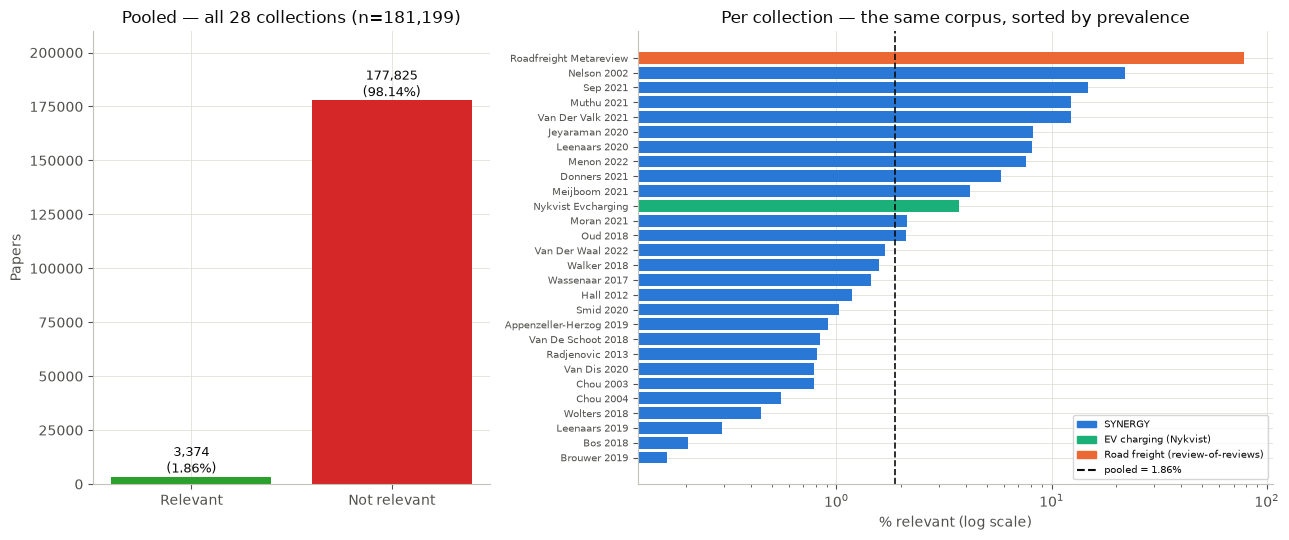

Takeaways:
- 3,374 of 181,199 papers are relevant (1.86%). Always answering 'not relevant' scores 98.14% accuracy — which is why accuracy appears nowhere in this notebook.
- Per collection, prevalence spans 0.16% (Brouwer 2019) to 78.03% (Roadfreight Metareview) — a 480x spread. The pooled bar on the left is not a description of any one of them.
- roadfreight_metareview is the far-right outlier and a different task: it selects review papers, not individual studies. It is excluded from headline averages throughout.


In [4]:
label_counts = df["triage_label"].value_counts().reindex(LABEL_ORDER)
label_pct = label_counts / label_counts.sum() * 100

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 5.5),
                                 gridspec_kw={"width_ratios": [1, 1.6]})

bars = ax_l.bar([LABEL_DISPLAY[l] for l in LABEL_ORDER], label_counts.values,
                color=[LABEL_COLORS[l] for l in LABEL_ORDER])
for bar, count, pct in zip(bars, label_counts.values, label_pct.values):
    ax_l.annotate(f"{count:,}\n({pct:.2f}%)",
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                  ha="center", va="bottom", fontsize=9)
ax_l.set_ylabel(FEATURE_DISPLAY["n_papers"])
ax_l.set_title(f"Pooled — all 28 collections (n={len(df):,})")
ax_l.margins(y=0.18)

positions = np.arange(len(UC_ORDER))
ax_r.barh(positions, [prevalence[uc] * 100 for uc in UC_ORDER],
          color=[UC_COLOR[uc] for uc in UC_ORDER])
pooled_pct = df["label_positive"].mean() * 100
ax_r.axvline(pooled_pct, color="#0b0b0b", linestyle="--", linewidth=1.2,
             label=f"pooled = {pooled_pct:.2f}%")
ax_r.set_yticks(positions)
ax_r.set_yticklabels([display_name(uc) for uc in UC_ORDER], fontsize=7)
ax_r.set_xscale("log")
ax_r.set_xlabel("% relevant (log scale)")
ax_r.set_title("Per collection — the same corpus, sorted by prevalence")
ax_r.legend(fontsize=8, loc="lower right")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FAMILY_COLORS.values()]
ax_r.legend(handles + [plt.Line2D([0], [0], color="#0b0b0b", linestyle="--")],
            list(FAMILY_COLORS) + [f"pooled = {pooled_pct:.2f}%"],
            fontsize=7, loc="lower right")
plt.tight_layout()
export_fig(fig, "1_total_by_label")

summary = pd.DataFrame({
    "family": [family_of(uc) for uc in UC_ORDER],
    "n_papers": [int((df["use_case_key"] == uc).sum()) for uc in UC_ORDER],
    "positive": [int(df.loc[df["use_case_key"] == uc, "label_positive"].sum()) for uc in UC_ORDER],
    "prevalence": [float(prevalence[uc]) for uc in UC_ORDER],
}, index=pd.Index(UC_ORDER, name="use_case_key"))
export_table(summary, "1_total_by_label")
plt.show()

ratio = prevalence.max() / prevalence.min()
print("Takeaways:")
print(f"- {label_counts['positive']:,} of {len(df):,} papers are relevant ({label_pct['positive']:.2f}%). "
      f"Always answering 'not relevant' scores {label_pct['negative']:.2f}% accuracy — which is why "
      "accuracy appears nowhere in this notebook.")
print(f"- Per collection, prevalence spans {prevalence.min():.2%} ({display_name(prevalence.idxmin())}) "
      f"to {prevalence.max():.2%} ({display_name(prevalence.idxmax())}) — a {ratio:.0f}x spread. "
      "The pooled bar on the left is not a description of any one of them.")
print(f"- {EXCLUDE_FROM_HEADLINE} is the far-right outlier and a different task: it selects "
      "review papers, not individual studies. It is excluded from headline averages throughout.")

## 3. Slide — each question, its size, and how much of it is relevant

`02_eda_quickstart.ipynb` stacks each use case's labels in one bar. That does not survive
the move to this corpus: at 1.86% positive a stacked bar is a solid block of "not
relevant" with an invisible sliver on the end, for 26 of the 28 collections.

So the same information is shown the way it stays readable — size and positive count on
log axes, with the 40-positive line that decides whether a collection can be split at
all. The briefs go to the CSV, where a reader can actually read them.

  saved ../../reports/eda_quickstart_benchset_v1_2_use_cases_by_label.png
  saved ../../reports/eda_quickstart_benchset_v1_2_use_cases_by_label.csv


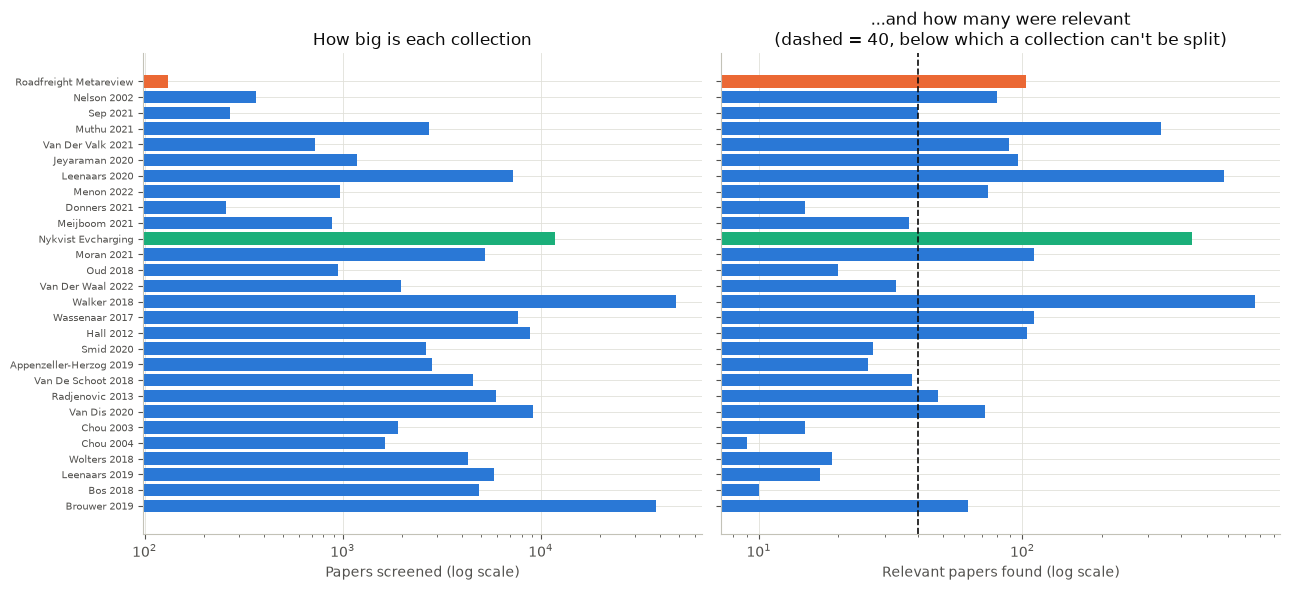

Takeaways:
- Collections span 132 to 48,343 papers (366x) and 9 to 760 relevant papers.
- 12 of 28 collections have fewer than 40 relevant papers — evaluation-only surfaces. 16 can support a within-collection train/test split.
- Full question text (use_case_name + objective) is in the exported CSV, not the chart — 28 briefs do not fit on a slide.


In [5]:
fig, (ax_n, ax_p) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
positions = np.arange(len(UC_ORDER))

ax_n.barh(positions, summary["n_papers"], color=[UC_COLOR[uc] for uc in UC_ORDER])
ax_n.set_xscale("log")
ax_n.set_xlabel("Papers screened (log scale)")
ax_n.set_title("How big is each collection")
ax_n.set_yticks(positions)
ax_n.set_yticklabels([display_name(uc) for uc in UC_ORDER], fontsize=7)

ax_p.barh(positions, summary["positive"], color=[UC_COLOR[uc] for uc in UC_ORDER])
ax_p.axvline(MIN_POSITIVES_TO_SPLIT, color="#0b0b0b", linestyle="--", linewidth=1.2)
ax_p.set_xscale("log")
ax_p.set_xlabel("Relevant papers found (log scale)")
ax_p.set_title(f"...and how many were relevant\n(dashed = {MIN_POSITIVES_TO_SPLIT}, "
               "below which a collection can't be split)")
plt.tight_layout()
export_fig(fig, "2_use_cases_by_label")

briefs_table = (
    df.groupby("use_case_key", observed=True)
      .agg(use_case_name=("use_case_name", "first"), objective=("objective", "first"))
      .reindex(UC_ORDER)
      .join(summary[["family", "n_papers", "positive", "prevalence"]])
)
briefs_table["too_small_to_split"] = briefs_table["positive"] < MIN_POSITIVES_TO_SPLIT
export_table(briefs_table, "2_use_cases_by_label")
plt.show()

n_small = int(briefs_table["too_small_to_split"].sum())
print("Takeaways:")
print(f"- Collections span {summary['n_papers'].min():,} to {summary['n_papers'].max():,} papers "
      f"({summary['n_papers'].max() / summary['n_papers'].min():.0f}x) and "
      f"{summary['positive'].min()} to {summary['positive'].max()} relevant papers.")
print(f"- {n_small} of {len(UC_ORDER)} collections have fewer than {MIN_POSITIVES_TO_SPLIT} "
      f"relevant papers — evaluation-only surfaces. {len(UC_ORDER) - n_small} can support a "
      "within-collection train/test split.")
print("- Full question text (use_case_name + objective) is in the exported CSV, not the chart — "
      "28 briefs do not fit on a slide.")

## 4. Slide — missingness, across the features that matter

`NULL != 0` is non-negotiable in this project: "never found out" and "found nothing" are
different facts, so nothing here is `fillna(0)`'d.

**The trap, and it is the opposite of the TIRI corpus's:** a missing abstract here is a
genuine `NULL`. In `papers_combined.parquet` it is an empty string, and
`02_eda_quickstart.ipynb` §4 warns that `abstract.isna()` reports zero missing there.
Code moved between the two corpora without checking will be wrong in one of them. Use
`has_abstract`, which `01_data_compile_benchset_v1.ipynb` §6 builds after asserting which
convention actually holds.

The right panel is new here: abstract coverage varies enormously *by collection*
(one is missing 23%), and a by-label view alone hides that completely.

  saved ../../reports/eda_quickstart_benchset_v1_3_missingness.png
  saved ../../reports/eda_quickstart_benchset_v1_3_missingness.csv
  saved ../../reports/eda_quickstart_benchset_v1_3_missingness_by_collection.csv


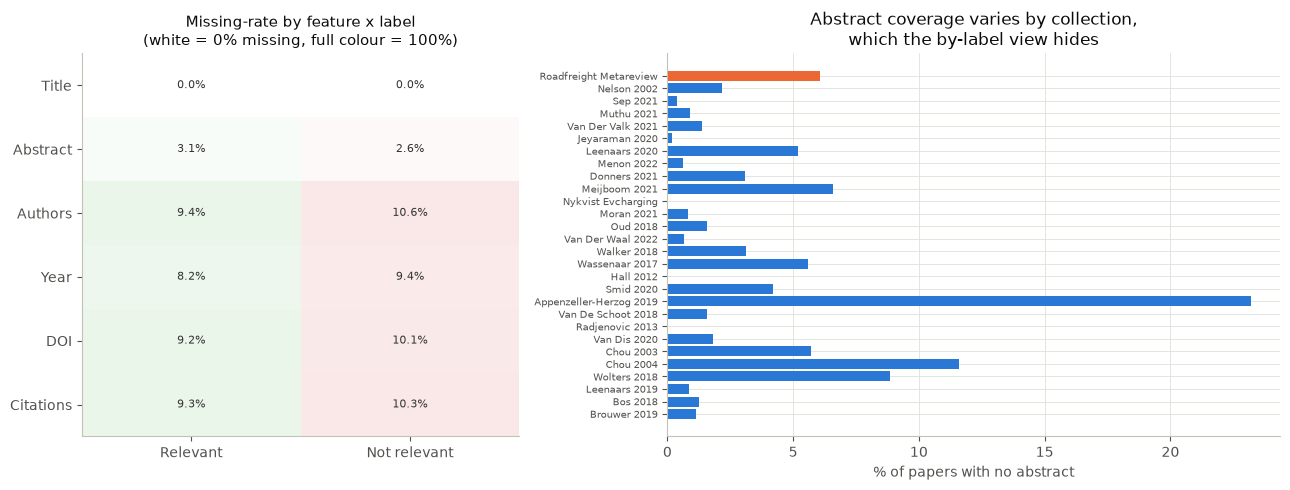

Takeaways:
- Corpus-wide 2.6% of papers have no abstract — but per collection that runs 0.0% to 23.2% (Appenzeller-Herzog 2019). Any text feature is title-only for those rows.
- Missingness by label is nearly flat: relevant and not-relevant papers differ by at most 1.2% on any feature. Unlike the TIRI corpus's 'pass' class, no label here is a metadata-completeness artefact — expected, since these labels come from published reviews, not a triage queue.
- title and triage_label are 100% present by construction; the metadata that was rehydrated from OpenAlex/Crossref (authors, year, doi, citations) is what carries gaps.


In [6]:
FEATURES = ["title", "abstract_present", "authors", "year", "doi", "citation_count"]
df["abstract_present"] = df["has_abstract"]

group_order = [LABEL_DISPLAY[l] for l in LABEL_ORDER]
label_groups = df["triage_label"].astype("object").map(LABEL_DISPLAY)

missing_rate = pd.DataFrame(index=FEATURES, columns=group_order, dtype=float)
for feat in FEATURES:
    missing = ~df[feat] if feat == "abstract_present" else df[feat].isna()
    missing_rate.loc[feat] = missing.groupby(label_groups).mean().reindex(group_order)
missing_rate.index = [FEATURE_DISPLAY[f] for f in FEATURES]

fig, (ax_h, ax_b) = plt.subplots(1, 2, figsize=(13, 5),
                                 gridspec_kw={"width_ratios": [1, 1.4]})

white = np.array([1.0, 1.0, 1.0])
rgb_grid = np.zeros((len(missing_rate.index), len(group_order), 3))
for j, lab in enumerate(LABEL_ORDER):
    base = np.array(mcolors.to_rgb(LABEL_COLORS[lab]))
    for i in range(len(missing_rate.index)):
        rgb_grid[i, j] = white + (base - white) * missing_rate.values[i, j]

ax_h.imshow(rgb_grid, aspect="auto")
ax_h.set_xticks(range(len(group_order)))
ax_h.set_xticklabels(group_order)
ax_h.set_yticks(range(len(missing_rate.index)))
ax_h.set_yticklabels(missing_rate.index)
ax_h.grid(False)
for i in range(missing_rate.shape[0]):
    for j in range(missing_rate.shape[1]):
        lum = rgb_grid[i, j] @ np.array([0.2126, 0.7152, 0.0722])
        ax_h.text(j, i, f"{missing_rate.values[i, j]:.1%}", ha="center", va="center",
                  color="white" if lum < 0.6 else "#333333", fontsize=8)
ax_h.set_title("Missing-rate by feature x label\n(white = 0% missing, full colour = 100%)",
               fontsize=11)

abstract_missing_by_uc = (
    1 - df.groupby("use_case_key", observed=True)["has_abstract"].mean()
).reindex(UC_ORDER)
positions = np.arange(len(UC_ORDER))
ax_b.barh(positions, abstract_missing_by_uc.values * 100,
          color=[UC_COLOR[uc] for uc in UC_ORDER])
ax_b.set_yticks(positions)
ax_b.set_yticklabels([display_name(uc) for uc in UC_ORDER], fontsize=7)
ax_b.set_xlabel("% of papers with no abstract")
ax_b.set_title("Abstract coverage varies by collection,\nwhich the by-label view hides")
plt.tight_layout()
export_fig(fig, "3_missingness")
export_table(missing_rate, "3_missingness")
export_table(abstract_missing_by_uc.rename("pct_abstract_missing").to_frame(),
             "3_missingness_by_collection")
plt.show()

worst_uc = abstract_missing_by_uc.idxmax()
print("Takeaways:")
print(f"- Corpus-wide {(~df['has_abstract']).mean():.1%} of papers have no abstract — but per "
      f"collection that runs {abstract_missing_by_uc.min():.1%} to "
      f"{abstract_missing_by_uc.max():.1%} ({display_name(worst_uc)}). Any text feature is "
      "title-only for those rows.")
print(f"- Missingness by label is nearly flat: relevant and not-relevant papers differ by at "
      f"most {abs(missing_rate[group_order[0]] - missing_rate[group_order[1]]).max():.1%} on any "
      "feature. Unlike the TIRI corpus's 'pass' class, no label here is a metadata-completeness "
      "artefact — expected, since these labels come from published reviews, not a triage queue.")
print(f"- title and triage_label are 100% present by construction; the metadata that was "
      "rehydrated from OpenAlex/Crossref (authors, year, doi, citations) is what carries gaps.")

## 5. Slide — data skew: citations, age, and authors by collection

`citation_count` is heavily right-skewed, so it's shown log-scaled. `paper_age` and
`n_authors` are derived exactly as `04_feature_engineering.ipynb` derives them (age from
the export timestamp, not a hardcoded "current year"; authors from a comma-split), so
this slide and any downstream feature table can't quietly disagree.

One caveat specific to this corpus: `exported_at` is the benchset's build date and is the
same for all 28 collections, so `paper_age` here is a clean function of `year` — unlike
the TIRI corpus, where six exports carried six timestamps.

  saved ../../reports/eda_quickstart_benchset_v1_4_skew_by_use_case.png
  saved ../../reports/eda_quickstart_benchset_v1_4_skew_by_use_case.csv


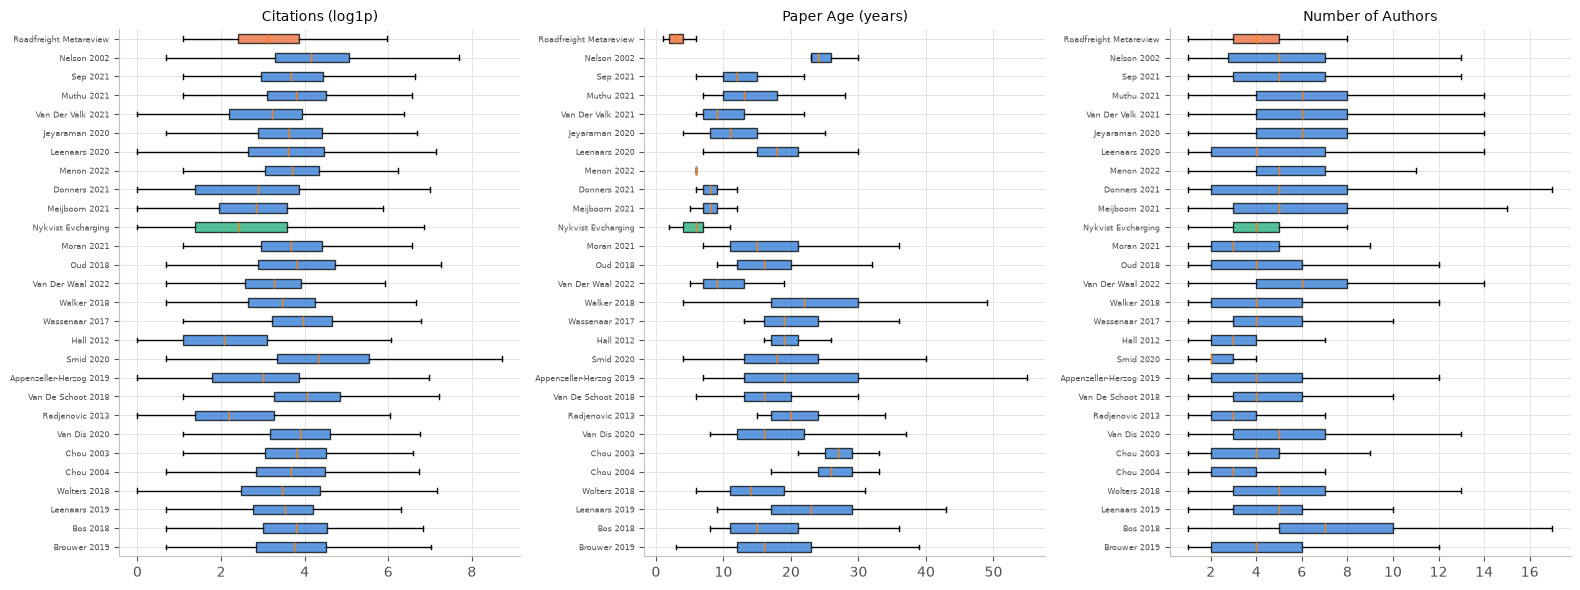

Takeaways:
- Median paper age runs 3 to 27 years (Roadfreight Metareview newest, Chou 2003 oldest). Year is a collection fingerprint when pooling, and admissible only within a silo (CONTEXT.md §1).
- Median citation count runs 7 to 75 across collections — a raw citation feature is partly measuring which collection a paper is in.
- Boxplots hide outliers by design (showfliers=False); full-precision numbers are in the exported CSV.


In [7]:
exported_year = pd.to_datetime(df["exported_at"]).dt.year
df["paper_age"] = (exported_year - df["year"]).clip(lower=0)


def count_authors(value):
    if pd.isna(value) or str(value).strip() == "":
        return np.nan
    return float(len(str(value).split(",")))


df["n_authors"] = df["authors"].map(count_authors)
df["citation_count_log1p"] = np.log1p(df["citation_count"])

metrics = [
    ("citation_count_log1p", f"{FEATURE_DISPLAY['citation_count_log1p']} (log1p)"),
    ("paper_age", f"{FEATURE_DISPLAY['paper_age']} (years)"),
    ("n_authors", FEATURE_DISPLAY["n_authors"]),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (col, label) in zip(axes, metrics):
    data = [df.loc[df["use_case_key"] == uc, col].dropna().values for uc in UC_ORDER]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, orientation="horizontal")
    for patch, uc in zip(bp["boxes"], UC_ORDER):
        patch.set_facecolor(UC_COLOR[uc])
        patch.set_alpha(0.75)
    ax.set_yticks(range(1, len(UC_ORDER) + 1))
    ax.set_yticklabels([display_name(uc) for uc in UC_ORDER], fontsize=6)
    ax.set_title(label, fontsize=10)
plt.tight_layout()
export_fig(fig, "4_skew_by_use_case")

skew_summary = (
    df.groupby("use_case_key", observed=True)[["citation_count", "paper_age", "n_authors"]]
      .agg(["median", "mean", "std"]).reindex(UC_ORDER)
)
export_table(skew_summary, "4_skew_by_use_case")
plt.show()

age_medians = df.groupby("use_case_key", observed=True)["paper_age"].median().reindex(UC_ORDER)
cite_medians = df.groupby("use_case_key", observed=True)["citation_count"].median().reindex(UC_ORDER)
print("Takeaways:")
print(f"- Median paper age runs {age_medians.min():.0f} to {age_medians.max():.0f} years "
      f"({display_name(age_medians.idxmin())} newest, {display_name(age_medians.idxmax())} oldest). "
      "Year is a collection fingerprint when pooling, and admissible only within a silo "
      "(CONTEXT.md §1).")
print(f"- Median citation count runs {cite_medians.min():.0f} to {cite_medians.max():.0f} across "
      "collections — a raw citation feature is partly measuring which collection a paper is in.")
print("- Boxplots hide outliers by design (showfliers=False); full-precision numbers are in the "
      "exported CSV.")

## 6. Slide — the embedding map

The TIRI corpus ships a precomputed 384-dim embedding. This one ships none, so
`scripts/embed_benchsets.py` computes them: **Jasper-Token-Compression-600M (2048-dim)
and Qwen3-Embedding-4B (2560-dim)**, the pairing `reports/wf_embedding_bakeoff.md` §8
adopted and `papers_fe.parquet` already carries. Run that script before this notebook.

Two readings of the same space, as in `02_eda_quickstart.ipynb`: coloured by collection,
then by label. **The map is drawn from a stratified subsample** (a fixed number of papers
per collection) — 181,199 points would be an unreadable smear, and PCA over the full
matrix buys nothing a subsample doesn't show.

  saved ../../reports/eda_quickstart_benchset_v1_5_embeddings_pca.png


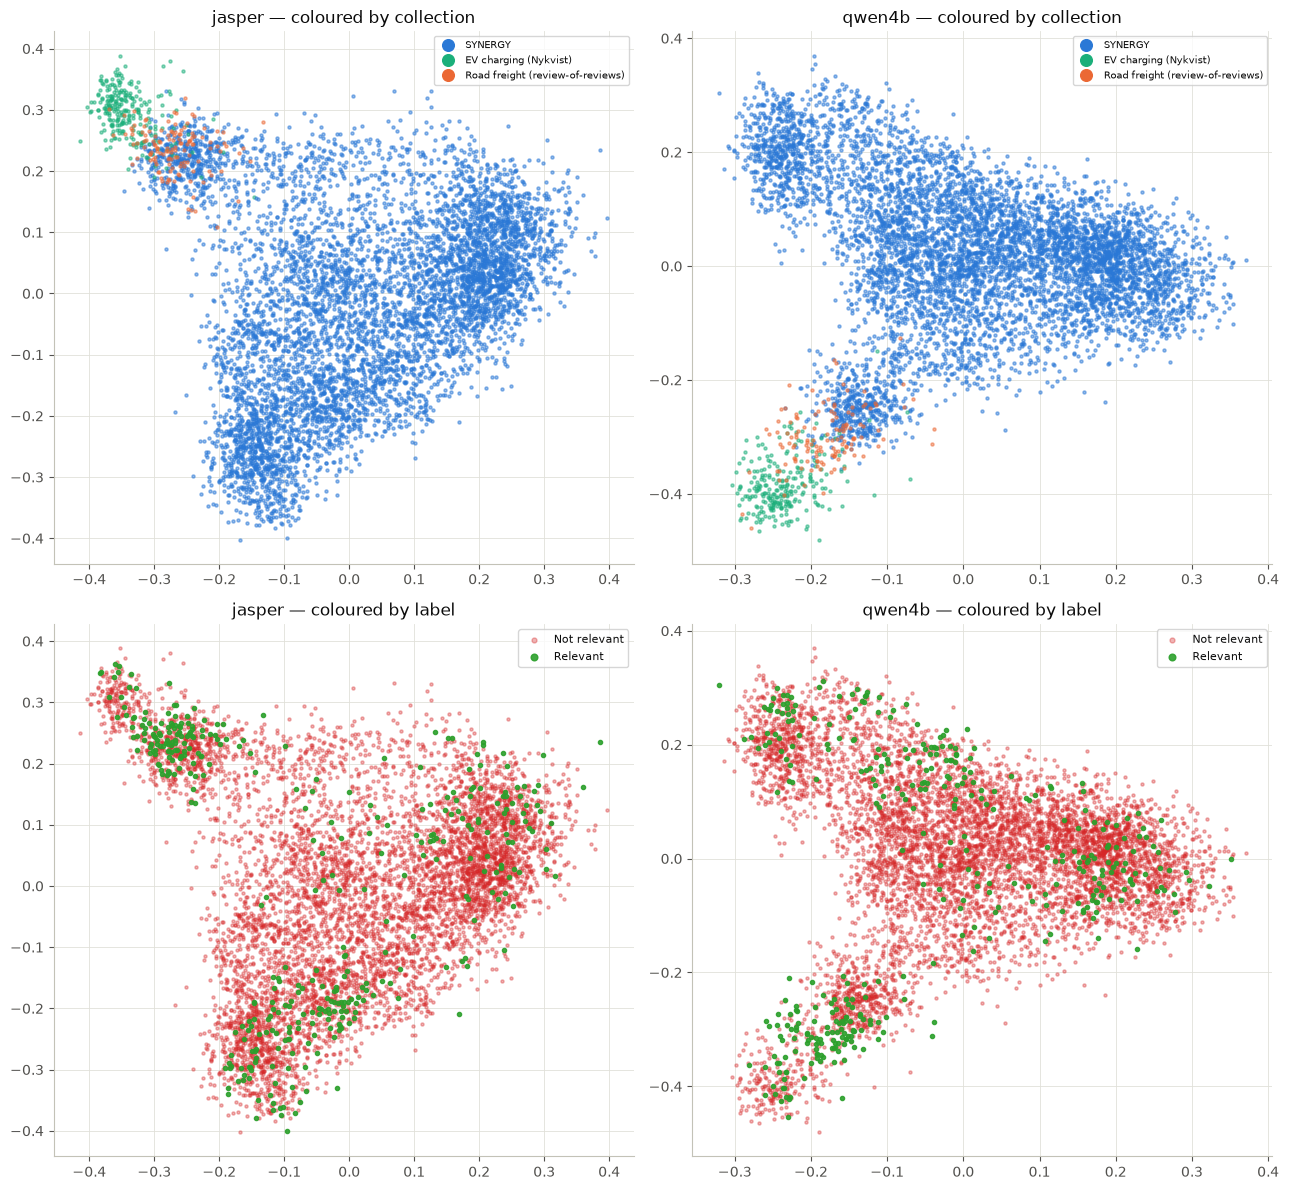

Map drawn from 6,882 papers (250 per collection, capped at collection size).


In [8]:
from sklearn.decomposition import PCA

EMBEDDING_MODELS = {
    "jasper": "infgrad__Jasper-Token-Compression-600M",
    "qwen4b": "Qwen__Qwen3-Embedding-4B",
}
MAP_SAMPLE_PER_UC = 250
rng = np.random.default_rng(0)


def load_collection_vectors(uc, cache_stem):
    path = CACHE_DIR / f"benchset_v1_{uc}_{cache_stem}_papers.parquet"
    if not path.exists():
        raise FileNotFoundError(
            f"{path.name} is missing — run `python scripts/embed_benchsets.py` first."
        )
    cached = pd.read_parquet(path)
    order = df.loc[df["use_case_key"] == uc, "paper_id"]
    return np.vstack(cached.set_index("paper_id").loc[order, "embedding"].to_numpy())


def load_briefs(cache_stem):
    briefs = pd.read_parquet(CACHE_DIR / f"benchset_v1_{cache_stem}_usecases.parquet")
    return {k: np.asarray(v, dtype=np.float32)
            for k, v in zip(briefs["use_case_key"], briefs["embedding"])}


# One stratified subsample, reused for both models so the two maps are comparable.
sample_idx = {}
for uc in UC_ORDER:
    rows = np.flatnonzero((df["use_case_key"] == uc).to_numpy())
    take = min(MAP_SAMPLE_PER_UC, len(rows))
    sample_idx[uc] = np.sort(rng.choice(rows, size=take, replace=False))

fig, axes = plt.subplots(2, 2, figsize=(13, 12))
for col, (short, stem) in enumerate(EMBEDDING_MODELS.items()):
    parts, keys = [], []
    for uc in UC_ORDER:
        vectors = load_collection_vectors(uc, stem)
        local = np.searchsorted(np.flatnonzero((df["use_case_key"] == uc).to_numpy()),
                                sample_idx[uc])
        parts.append(vectors[local])
        keys.extend([uc] * len(local))
    V = np.vstack(parts)
    keys = np.array(keys)
    global_rows = np.concatenate([sample_idx[uc] for uc in UC_ORDER])
    labels = df["label_positive"].to_numpy()[global_rows]

    coords = PCA(n_components=2, random_state=42).fit_transform(V)

    ax = axes[0, col]
    for uc in UC_ORDER:
        mask = keys == uc
        ax.scatter(coords[mask, 0], coords[mask, 1], s=5, alpha=0.5, color=UC_COLOR[uc])
    ax.set_title(f"{short} — coloured by collection")
    handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=c) for c in FAMILY_COLORS.values()]
    ax.legend(handles, list(FAMILY_COLORS), fontsize=7, markerscale=1.4, loc="best")

    ax = axes[1, col]
    ax.scatter(coords[labels == 0, 0], coords[labels == 0, 1], s=5, alpha=0.35,
               color=LABEL_COLORS["negative"], label=LABEL_DISPLAY["negative"])
    ax.scatter(coords[labels == 1, 0], coords[labels == 1, 1], s=9, alpha=0.9,
               color=LABEL_COLORS["positive"], label=LABEL_DISPLAY["positive"])
    ax.set_title(f"{short} — coloured by label")
    ax.legend(fontsize=8, markerscale=1.6, loc="best")

plt.tight_layout()
export_fig(fig, "5_embeddings_pca")
plt.show()
print(f"Map drawn from {len(global_rows):,} papers "
      f"({MAP_SAMPLE_PER_UC} per collection, capped at collection size).")

### Does the brief actually rank the relevant papers?

The dispersion table `02_eda_quickstart.ipynb` reports is a pairwise-cosine mean over the
whole corpus. That is O(n²) — at 181,199 papers it is a 32-billion-entry matrix — so it is
computed **per collection on a capped subsample** here instead.

More useful, and possible for the first time on this corpus: **cosine-to-brief as a
zero-label ranker**, scored per collection. Nothing is fitted and no label is consulted to
produce the ranking, so it is a legitimate held-out number rather than a train-then-score
one. `CONTEXT.md` §2 calls this the strongest signal available at zero labels.

**Read the printed caveat below before quoting any of these numbers.** They come out far
higher than the same measurement on the TIRI corpus, and the reason is a property of how
these briefs were made, not evidence that the method got better.

In [9]:
from sklearn.metrics import roc_auc_score

DISPERSION_SAMPLE = 400
brief_vectors = {short: load_briefs(stem) for short, stem in EMBEDDING_MODELS.items()}


def mean_pairwise_cosine(Vn):
    sims = Vn @ Vn.T
    return float(sims[np.triu_indices_from(sims, k=1)].mean())


# A within-collection dispersion number means nothing without something to compare it
# to, so the same statistic is computed over a sample drawn ACROSS collections. That
# cross-collection figure is the baseline the original notebook calls "corpus-wide".
cross_collection = {}
for short, stem in EMBEDDING_MODELS.items():
    picks = []
    for uc in UC_ORDER:
        V = load_collection_vectors(uc, stem)
        take = min(15, len(V))
        picks.append(V[np.sort(rng.choice(len(V), size=take, replace=False))])
    Vc = np.vstack(picks)
    Vc = Vc / (np.linalg.norm(Vc, axis=1, keepdims=True) + 1e-9)
    cross_collection[short] = mean_pairwise_cosine(Vc)

rows = []
for uc in UC_ORDER:
    y = df.loc[df["use_case_key"] == uc, "label_positive"].to_numpy()
    row = {"family": family_of(uc), "n_papers": len(y), "positive": int(y.sum()),
           "prevalence": float(y.mean())}
    for short, stem in EMBEDDING_MODELS.items():
        V = load_collection_vectors(uc, stem)
        Vn = V / (np.linalg.norm(V, axis=1, keepdims=True) + 1e-9)

        take = min(DISPERSION_SAMPLE, len(Vn))
        sub = Vn[np.sort(rng.choice(len(Vn), size=take, replace=False))]
        row[f"{short}_dispersion"] = mean_pairwise_cosine(sub)

        brief = brief_vectors[short][uc]
        cos = Vn @ (brief / (np.linalg.norm(brief) + 1e-9))
        row[f"{short}_cos_brief_auc"] = (
            float(roc_auc_score(y, cos)) if 0 < y.sum() < len(y) else np.nan
        )
    rows.append(row)

brief_table = pd.DataFrame(rows, index=pd.Index(UC_ORDER, name="use_case_key"))
export_table(brief_table, "5_embeddings_dispersion")

headline = brief_table.drop(index=EXCLUDE_FROM_HEADLINE)
print(brief_table.round(3).to_string())
print()
print("Takeaways (roadfreight_metareview excluded from every average below — it is a "
      "review-of-reviews at 78% positive, not a screening task):")
for short in EMBEDDING_MODELS:
    auc = headline[f"{short}_cos_brief_auc"]
    print(f"- {short}: cosine-to-brief ROC-AUC median {auc.median():.3f}, "
          f"mean {auc.mean():.3f}, beats chance on {int((auc > 0.5).sum())}/{len(auc)} "
          f"collections (range {auc.min():.3f}-{auc.max():.3f}).")

j_wins = int((headline["jasper_cos_brief_auc"] > headline["qwen4b_cos_brief_auc"]).sum())
print(f"- Head to head, qwen4b ranks better on {len(headline) - j_wins}/{len(headline)} "
      f"collections and jasper on {j_wins}/{len(headline)} — a win count, not a mean "
      "difference, per CONTEXT.md §5.")

print(f"\n- TREAT THESE NUMBERS WITH SUSPICION. A zero-label ranker scoring a median "
      f"~{headline['qwen4b_cos_brief_auc'].median():.2f} ROC-AUC at 1.86% prevalence would "
      "be a remarkable result if the briefs were real. They are not: each was LLM-drafted "
      "from its review's own title and abstract, i.e. from a summary of the papers that "
      "got INCLUDED. Matching papers to that text is partly matching them to a description "
      "of themselves. The corpus README flags this ('closer to the answer than a brief "
      "written before screening'); this is the first quantification of how much.")
print("  For scale: on the TIRI corpus, whose briefs were written by hand before "
      "screening, cosine-to-brief reaches 0.693 LOGO ROC-AUC (CONTEXT.md §2). Use these "
      "collections to compare methods against each other, never to claim an absolute "
      "level of performance.")

print(f"\n- Within-collection dispersion (mean pairwise cosine, {DISPERSION_SAMPLE}-paper "
      "subsample) vs. the same statistic across collections:")
for short in EMBEDDING_MODELS:
    within = headline[f"{short}_dispersion"].mean()
    print(f"    {short:8s} within-collection {within:.3f}  |  cross-collection "
          f"{cross_collection[short]:.3f}  (gap {within - cross_collection[short]:+.3f})")
print("  Papers inside one collection are more alike than papers drawn from different "
      "ones, which is why a model trained across collections learns which collection it "
      "is looking at rather than what relevance is.")

  saved ../../reports/eda_quickstart_benchset_v1_5_embeddings_dispersion.csv
                                                           family  n_papers  positive  prevalence  jasper_dispersion  jasper_cos_brief_auc  qwen4b_dispersion  qwen4b_cos_brief_auc
use_case_key                                                                                                                                                                       
synergy_brouwer_2019                                      SYNERGY     38114        62       0.002              0.535                 0.994              0.420                 0.993
synergy_bos_2018                                          SYNERGY      4877        10       0.002              0.632                 0.986              0.530                 0.980
synergy_leenaars_2019                                     SYNERGY      5812        17       0.003              0.625                 0.990              0.503                 0.995
synergy_wolters_2018   

## Exported files

Everything a slide could need, written by the sections above. Note the
`eda_quickstart_benchset_v1_*` prefix — the TIRI corpus's `eda_quickstart_*` files are
left untouched, per this repo's convention of naming outputs after their input so two
corpora never overwrite each other.

In [10]:
for path in sorted(REPORTS_DIR.glob("eda_quickstart_benchset_v1_*")):
    print(f"{path.name:58s} {path.stat().st_size / 1024:>8.1f} KB")

eda_quickstart_benchset_v1_1_total_by_label.csv                 1.7 KB
eda_quickstart_benchset_v1_1_total_by_label.png               122.1 KB
eda_quickstart_benchset_v1_2_use_cases_by_label.csv            33.1 KB
eda_quickstart_benchset_v1_2_use_cases_by_label.png           101.7 KB
eda_quickstart_benchset_v1_3_missingness.csv                    0.3 KB
eda_quickstart_benchset_v1_3_missingness.png                  119.0 KB
eda_quickstart_benchset_v1_3_missingness_by_collection.csv      1.1 KB
eda_quickstart_benchset_v1_4_skew_by_use_case.csv               4.1 KB
eda_quickstart_benchset_v1_4_skew_by_use_case.png             198.4 KB
eda_quickstart_benchset_v1_5_embeddings_dispersion.csv          3.8 KB
eda_quickstart_benchset_v1_5_embeddings_pca.png              1229.0 KB


## Where to go next

- **`01_data_compile_benchset_v1.ipynb`** — how this parquet was verified into existence,
  and the two findings worth reading: 130 papers labelled both ways depending on the
  question, and the NULL-vs-empty-string abstract convention.
- **`03_eda_full_benchset_v1.ipynb`** — the full pass: per-collection statistics,
  duplicate/leakage analysis, and within-collection baselines on the 16 collections big
  enough to split.
- **`scripts/embed_benchsets.py`** — the Jasper + Qwen3-4B vectors section 6 reads.
- **`data/benchsets_v1/README.md`** — the corpus's own data card, including the five
  things it warns will bite you. Three of them (pooled prevalence, the 12 small
  collections, `roadfreight_metareview`) are re-derived above rather than quoted.
- **`CONTEXT.md`** — §1 (no pooled model ever ships), §3 (data facts that will bite you)
  and §5 (the statistical discipline this repo requires) before proposing modelling work.
- Root **`CLAUDE.md`** — NULL != 0, cross-validate honestly, label which critic is
  speaking.